# Titanic Data EDA (Exploratory Data Analysis)

## Performed this EDA to practice the Pandas and use of code in different scenarion's **"My First EDA practice Using PYTHON"**

# **Imported all the libraries needed**

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 

In [2]:
#Load the data set

df=pd.read_csv("train.csv")

In [3]:
df.head() # Data view of first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [14]:
print(df.info()) #shows basic info of the data like number of columns, rows, nulls, data type of each column
print(df.isnull().sum()) # shows count of null values
print(df.describe())  # descriptive statistics of columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

In [17]:
 df["Age"]=df['Age'].fillna(df['Age'].median()) # replaced  NA value in "Age" column with median value in data

In [18]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()) # replaced  NA value in "Embarked" column with mode value in data

In [20]:
df.drop(["Cabin"], axis=1,inplace =True) # dropped Cabin column 

In [28]:
le= LabelEncoder() # encoded sex and embarked columns with numerics namely 0 and 1
df["Sex"] = le.fit_transform(df["Sex"])  #male = 1; Female =2
df["Embarked"] = le.fit_transform(df["Embarked"])

In [30]:
df.drop(["PassengerId","Name","Ticket"], axis =1, inplace = True) # in feature Engineering dropped columns "PassengerId","Name","Ticket".

In [32]:
df.columns #list of columns after feature Engineering

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

### Splitting Data into train and test

In [33]:
x= df.drop('Survived', axis =1)
y = df['Survived']  # New column called 'Survived'

x_test,x_train,y_test,y_train = train_test_split(x,y, test_size=0.2, random_state=42)

## As all the values are 0 and 1 'Binary' opted for logicstic regression and Decision tree models to predict the survival rate of passengers

### Logistic Regression

In [46]:
from sklearn.linear_model import LogisticRegression


lr_reg = LogisticRegression(max_iter = 200)
lr_reg.fit(x_train, y_train)
lr_pred = lr_reg.predict(x_test)

### Decision Tree Model

In [49]:
dt_mdl = DecisionTreeClassifier(random_state = 42)
dt_mdl.fit(x_train,y_train)
dt_prdt = dt_mdl.predict(x_test)

### Reports for both logistic Regression and decision Tree

In [54]:
print("Logistic_Regression Accuracy Score: " ,accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy Score: " ,accuracy_score(y_test,dt_prdt))


print("\nLogistic Regression Report:\n", classification_report(y_test, lr_pred))
print("\nDecision Tree Report: \n", classification_report(y_test, dt_prdt))

Logistic_Regression Accuracy Score:  0.7907303370786517
Decision Tree Accuracy Score:  0.7345505617977528

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84       444
           1       0.74      0.69      0.71       268

    accuracy                           0.79       712
   macro avg       0.78      0.77      0.77       712
weighted avg       0.79      0.79      0.79       712


Decision Tree Report: 
               precision    recall  f1-score   support

           0       0.79      0.78      0.79       444
           1       0.65      0.65      0.65       268

    accuracy                           0.73       712
   macro avg       0.72      0.72      0.72       712
weighted avg       0.74      0.73      0.73       712



### Visual represention of predictions with True positives and True negatives using Heat MAP **Confusion Matrix**

Text(0.5, 1.0, 'Logistic Regression Confusion matrix')

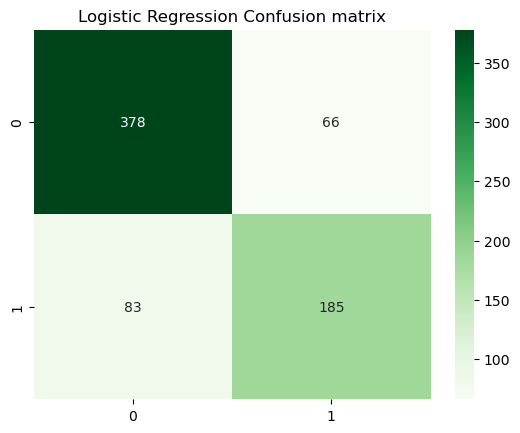

In [57]:
sns.heatmap(confusion_matrix(y_test,lr_pred), annot= True, fmt= 'd', cmap = 'Greens')
plt.title("Logistic Regression Confusion matrix")

Text(0.5, 1.0, 'Decision Tree Confusion matrix')

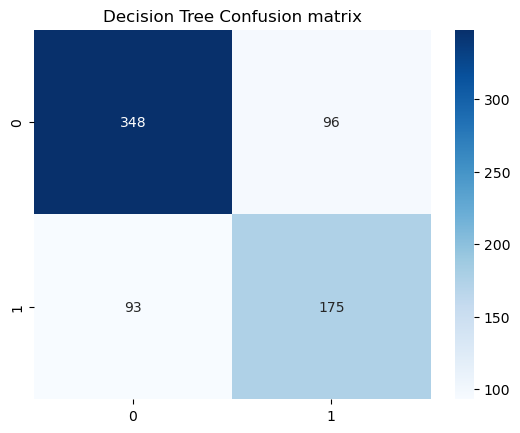

In [59]:
sns.heatmap(confusion_matrix(y_test,dt_prdt), annot= True, fmt= 'd', cmap = 'Blues')
plt.title("Decision Tree Confusion matrix")